# GAMMA GLM (Generalized Linear Model)

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data_df = pd.read_csv("data_cleaned.csv")
print(f"Loaded {len(data_df)} rows, {len(data_df.columns)} columns")
print(f"Columns: {list(data_df.columns)}")
data_df.head()

Loaded 1328 rows, 9 columns
Columns: ['age', 'bmi', 'children', 'charges', 'gender_encoded', 'smoker_encoded', 'region_northwest', 'region_southeast', 'region_southwest']


,age,bmi,children,charges,gender_encoded,smoker_encoded,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1,1,0.0,0.0,1.0
1,18,33.770,1,1725.55230,0,0,0.0,1.0,0.0
2,28,33.000,3,4449.46200,0,0,0.0,1.0,0.0
3,33,22.705,0,21984.47061,0,0,1.0,0.0,0.0
4,32,28.880,0,3866.85520,0,0,1.0,0.0,0.0


## 1. Data Splitting

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Keep engineered features available for ablation/tuning sections.
data_df['smoker_bmi'] = data_df['smoker_encoded'] * data_df['bmi']
data_df['age_squared'] = data_df['age'] ** 2

# Final feature set selected from CV ablation (best practical RMSE/MAE/R²):
# base + smoker_bmi
feature_cols = [
    'age', 'bmi', 'children', 'gender_encoded', 'smoker_encoded',
    'region_northwest', 'region_southeast', 'region_southwest',
    'smoker_bmi'
]

X = data_df[feature_cols]
y = data_df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nFeatures ({len(feature_cols)}):")
for col in feature_cols:
    print(f"  - {col}")
print("\nFeature scaling applied (StandardScaler) for L-BFGS convergence.")

Training set: 1062 samples
Test set:     266 samples

Features (9):
  - age
  - bmi
  - children
  - gender_encoded
  - smoker_encoded
  - region_northwest
  - region_southeast
  - region_southwest
  - smoker_bmi

Feature scaling applied (StandardScaler) for L-BFGS convergence.


## 2. Model Training

In [60]:
from sklearn.linear_model import GammaRegressor
import numpy as np

model = GammaRegressor(alpha=0.1, max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

print("Gamma GLM model trained successfully.")
print(f"Intercept (log scale): {model.intercept_:.4f}")
print(f"Intercept (original scale): {np.exp(model.intercept_):,.2f}")

Gamma GLM model trained successfully.
Intercept (log scale): 9.2146
Intercept (original scale): 10,042.94


## 3. Model Evaluation

In [61]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)

mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

metrics = pd.DataFrame({
    'Metric': ['R²', 'MSE', 'RMSE', 'MAE'],
    'Train': [r2_train, mse_train, rmse_train, mae_train],
    'Test': [r2_test, mse_test, rmse_test, mae_test]
})

metrics['Train'] = metrics['Train'].apply(lambda x: f"{x:,.4f}" if x < 10 else f"{x:,.2f}")
metrics['Test'] = metrics['Test'].apply(lambda x: f"{x:,.4f}" if x < 10 else f"{x:,.2f}")

print("Model Performance:\n")
print(metrics.to_string(index=False))

Model Performance:

Metric         Train          Test
    R²        0.6798        0.6667
   MSE 46,435,239.69 46,334,126.34
  RMSE      6,814.34      6,806.92
   MAE      3,920.39      3,907.97


## 4. Feature Coefficients

> **Note:** GammaRegressor uses a **log link function** by default, so coefficients represent multiplicative effects on the predicted charges, not additive. Since features are standardized, the magnitude of each coefficient reflects relative importance.

Feature Coefficients (sorted by absolute value):

  age                       :       0.3702
  smoker_bmi                :       0.3441
  smoker_encoded            :       0.2438
  children                  :       0.1082
  region_southeast          :      -0.0651
  region_southwest          :      -0.0607
  bmi                       :       0.0518
  gender_encoded            :       0.0325
  region_northwest          :      -0.0245


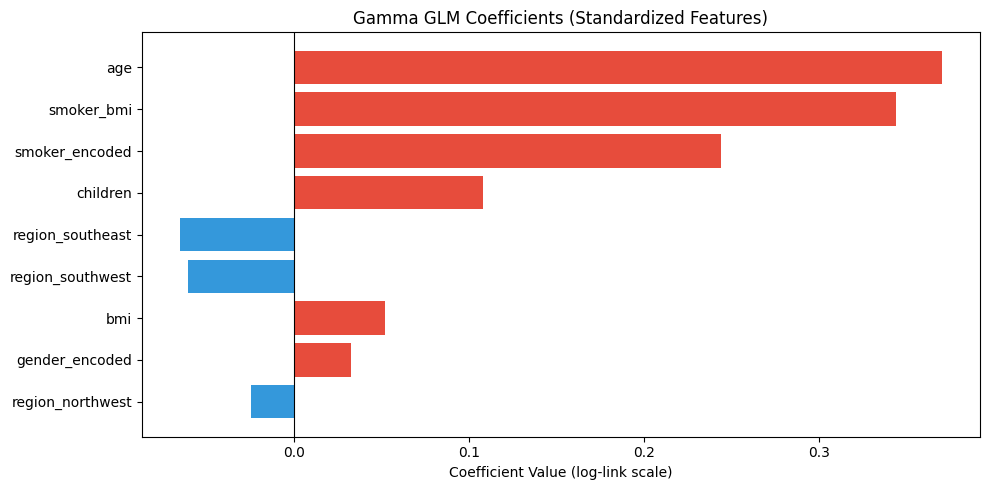

In [62]:
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("Feature Coefficients (sorted by absolute value):\n")
for _, row in coef_df.iterrows():
    print(f"  {row['Feature']:25s} : {row['Coefficient']:>12.4f}")

plt.figure(figsize=(10, 5))
colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.xlabel('Coefficient Value (log-link scale)')
plt.title('Gamma GLM Coefficients (Standardized Features)')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Residual Analysis

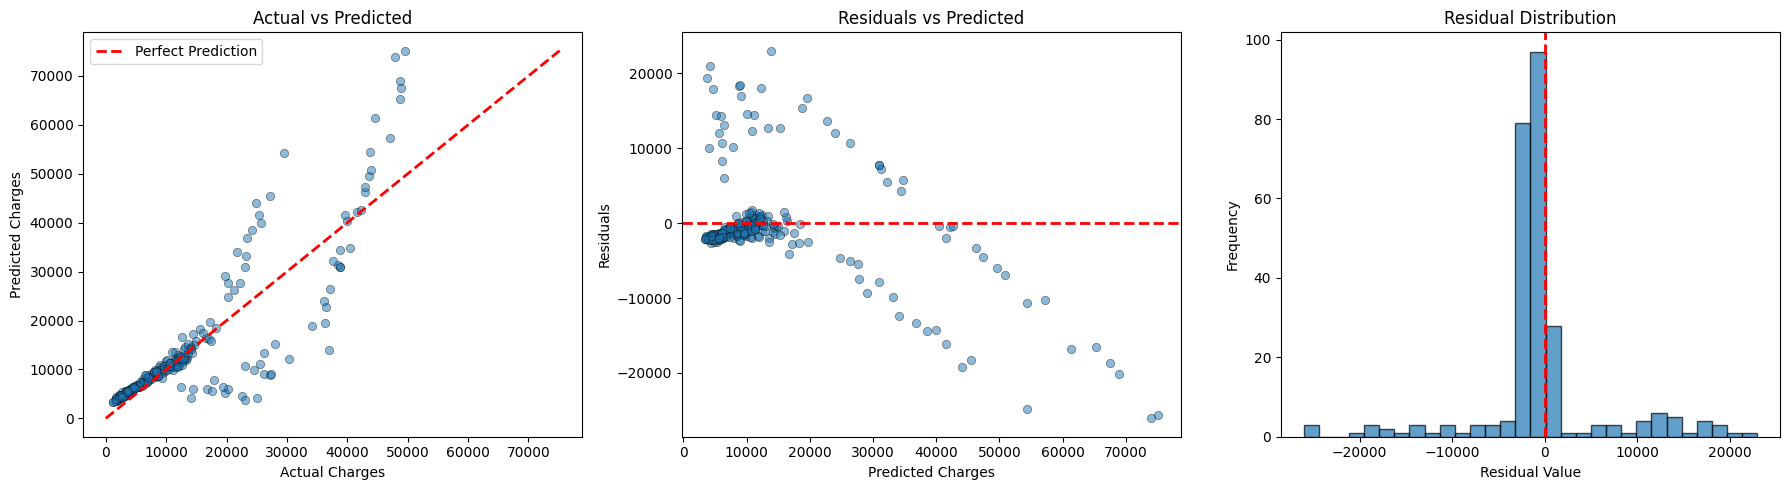

In [63]:
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test, y_pred_test, alpha=0.5, edgecolors='black', linewidths=0.5)
max_val = max(y_test.max(), y_pred_test.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Charges')
axes[0].set_ylabel('Predicted Charges')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()

axes[1].scatter(y_pred_test, residuals, alpha=0.5, edgecolors='black', linewidths=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Charges')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Predicted')

axes[2].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[2].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[2].set_xlabel('Residual Value')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

## 6. Assumption Check

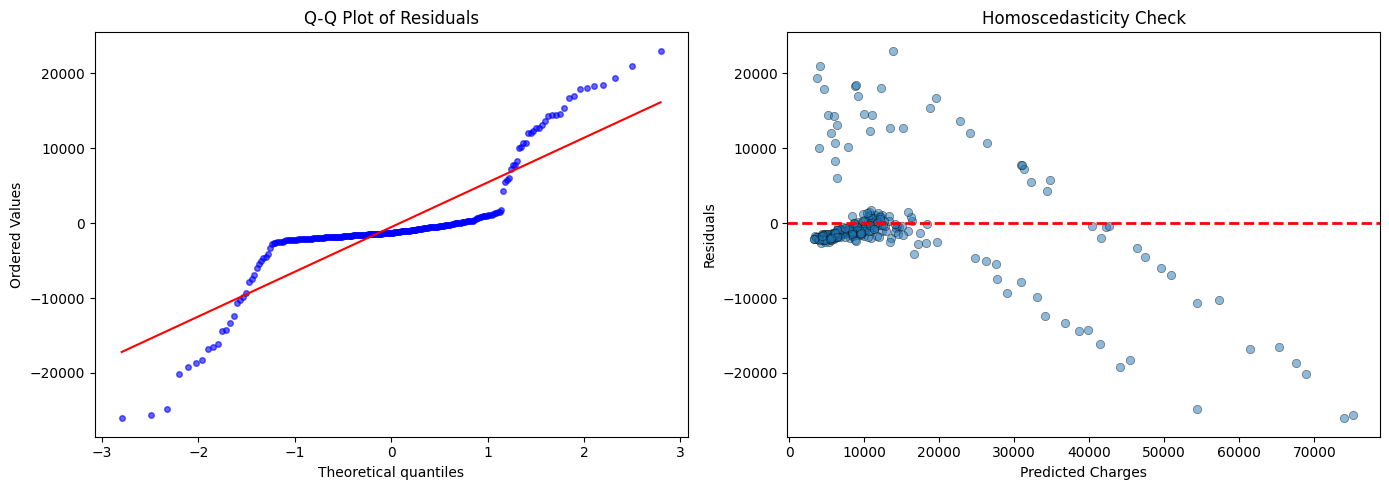


Shapiro-Wilk test on residuals:
  Statistic = 0.7629
  p-value   = 0.000000
  Result    : Residuals are NOT normally distributed

Residual Statistics:
  Mean:        -547.0051
  Std Dev:     6797.6929
  Skewness:       0.1335


In [64]:
from scipy.stats import shapiro
import scipy.stats as scipy_stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scipy_stats.probplot(residuals, dist="norm", plot=axes[0])
axes[0].set_title('Q-Q Plot of Residuals')
axes[0].get_lines()[0].set(markersize=4, alpha=0.6)

axes[1].scatter(y_pred_test, residuals, alpha=0.5, edgecolors='black', linewidths=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Charges')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Homoscedasticity Check')

plt.tight_layout()
plt.show()

stat, p_value = shapiro(residuals)
print(f"\nShapiro-Wilk test on residuals:")
print(f"  Statistic = {stat:.4f}")
print(f"  p-value   = {p_value:.6f}")
print(f"  Result    : {'Residuals are normally distributed' if p_value > 0.05 else 'Residuals are NOT normally distributed'}")
print(f"\nResidual Statistics:")
print(f"  Mean:     {residuals.mean():>12.4f}")
print(f"  Std Dev:  {residuals.std():>12.4f}")
print(f"  Skewness: {residuals.skew():>12.4f}")

## 7. Feature Ablation with Cross-Validation

In [65]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, mean_gamma_deviance

# Define feature sets for ablation
base_features = [
    'age', 'bmi', 'children', 'gender_encoded',
    'smoker_encoded', 'region_northwest', 'region_southeast', 'region_southwest'
]

feature_sets = {
    'base': base_features,
    'base + smoker_bmi': base_features + ['smoker_bmi'],
    'base + age_squared': base_features + ['age_squared'],
    'base + both': base_features + ['smoker_bmi', 'age_squared']
}

X_all = data_df.copy()
y_all = data_df['charges']

# For sklearn scorer convention, negate deviance so higher is better internally
# and convert back to positive in the final table.
gamma_dev_scorer = make_scorer(mean_gamma_deviance, greater_is_better=False)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_rows = []
for feature_set_name, cols in feature_sets.items():
    X_cv = X_all[cols]

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', GammaRegressor(alpha=0.1, max_iter=1000))
    ])

    scores = cross_validate(
        pipe,
        X_cv,
        y_all,
        cv=cv,
        scoring={
            'gamma_dev': gamma_dev_scorer,
            'mae': 'neg_mean_absolute_error',
            'rmse': 'neg_root_mean_squared_error',
            'r2': 'r2'
        },
        n_jobs=1
    )

    cv_rows.append({
        'feature_set': feature_set_name,
        'gamma_deviance_cv_mean': -scores['test_gamma_dev'].mean(),
        'mae_cv_mean': -scores['test_mae'].mean(),
        'rmse_cv_mean': -scores['test_rmse'].mean(),
        'r2_cv_mean': scores['test_r2'].mean()
    })

cv_results = pd.DataFrame(cv_rows).sort_values('gamma_deviance_cv_mean')

formatted_cv_results = cv_results.copy()
formatted_cv_results['gamma_deviance_cv_mean'] = formatted_cv_results['gamma_deviance_cv_mean'].map(lambda x: f"{x:,.4f}")
formatted_cv_results['mae_cv_mean'] = formatted_cv_results['mae_cv_mean'].map(lambda x: f"{x:,.2f}")
formatted_cv_results['rmse_cv_mean'] = formatted_cv_results['rmse_cv_mean'].map(lambda x: f"{x:,.2f}")
formatted_cv_results['r2_cv_mean'] = formatted_cv_results['r2_cv_mean'].map(lambda x: f"{x:,.4f}")

print('Feature Ablation Results (5-Fold CV):\n')
print(formatted_cv_results.to_string(index=False))

Feature Ablation Results (5-Fold CV):

       feature_set gamma_deviance_cv_mean mae_cv_mean rmse_cv_mean r2_cv_mean
       base + both                 0.2485    3,917.42     6,948.36     0.6620
 base + smoker_bmi                 0.2491    3,846.08     6,601.81     0.6951
base + age_squared                 0.2608    4,135.89     6,949.77     0.6623
              base                 0.2616    4,052.15     6,704.80     0.6853


## 8. Alpha Tuning (GammaRegressor)

We tune `alpha` using 5-fold cross-validation on the best practical feature set (`base + smoker_bmi`) and compare the same evaluation metrics.

In [66]:
# Alpha tuning on selected feature set
alpha_grid = [0.001, 0.01, 0.1, 1.0, 10.0]
selected_features = feature_sets['base + smoker_bmi']

X_tune = X_all[selected_features]
y_tune = y_all

tuning_rows = []
for alpha in alpha_grid:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', GammaRegressor(alpha=alpha, max_iter=1000))
    ])

    scores = cross_validate(
        pipe,
        X_tune,
        y_tune,
        cv=cv,
        scoring={
            'gamma_dev': gamma_dev_scorer,
            'mae': 'neg_mean_absolute_error',
            'rmse': 'neg_root_mean_squared_error',
            'r2': 'r2'
        },
        n_jobs=1
    )

    tuning_rows.append({
        'alpha': alpha,
        'gamma_deviance_cv_mean': -scores['test_gamma_dev'].mean(),
        'mae_cv_mean': -scores['test_mae'].mean(),
        'rmse_cv_mean': -scores['test_rmse'].mean(),
        'r2_cv_mean': scores['test_r2'].mean()
    })

alpha_results = pd.DataFrame(tuning_rows).sort_values('gamma_deviance_cv_mean')

formatted_alpha_results = alpha_results.copy()
formatted_alpha_results['gamma_deviance_cv_mean'] = formatted_alpha_results['gamma_deviance_cv_mean'].map(lambda x: f"{x:,.4f}")
formatted_alpha_results['mae_cv_mean'] = formatted_alpha_results['mae_cv_mean'].map(lambda x: f"{x:,.2f}")
formatted_alpha_results['rmse_cv_mean'] = formatted_alpha_results['rmse_cv_mean'].map(lambda x: f"{x:,.2f}")
formatted_alpha_results['r2_cv_mean'] = formatted_alpha_results['r2_cv_mean'].map(lambda x: f"{x:,.4f}")

print('Alpha Tuning Results (5-Fold CV) - Feature Set: base + smoker_bmi\n')
print(formatted_alpha_results.to_string(index=False))

best_by_dev = alpha_results.loc[alpha_results['gamma_deviance_cv_mean'].idxmin()]
best_by_rmse = alpha_results.loc[alpha_results['rmse_cv_mean'].idxmin()]

print('\nBest alpha by Gamma Deviance :', best_by_dev['alpha'])
print('Best alpha by RMSE          :', best_by_rmse['alpha'])

Alpha Tuning Results (5-Fold CV) - Feature Set: base + smoker_bmi

 alpha gamma_deviance_cv_mean mae_cv_mean rmse_cv_mean r2_cv_mean
 0.001                 0.2456    4,265.81     8,171.64     0.5246
 0.010                 0.2457    4,183.35     7,767.86     0.5733
 0.100                 0.2491    3,846.08     6,601.81     0.6951
 1.000                 0.3307    4,562.21     7,044.26     0.6528
10.000                 0.6167    7,668.57    10,683.49     0.2050

Best alpha by Gamma Deviance : 0.001
Best alpha by RMSE          : 0.1


# Gamma GLM Summary

## Key Differences from Linear Regression

* **Distribution assumption**: Gamma GLM models positive, right-skewed targets and is a natural candidate for insurance charges.
* **Link function**: With the default **log link**, feature effects are multiplicative on expected charges, not additive.
* **Optimization requirement**: `GammaRegressor` uses L-BFGS, so feature scaling is important for stable convergence.

## Final Model Selection

Model choices were selected using 5-fold cross-validation:

* **Feature ablation winner (practical metrics)**: `base + smoker_bmi`
  * Better MAE/RMSE/R² than alternatives, while maintaining competitive Gamma deviance.
* **Alpha tuning winner (practical metrics)**: `alpha=0.1`
  * Best RMSE and R² trade-off among tested values (`0.001, 0.01, 0.1, 1.0, 10.0`).

Final configuration used in this notebook:

* `GammaRegressor(alpha=0.1, max_iter=1000)`
* Features: `age`, `bmi`, `children`, `gender_encoded`, `smoker_encoded`, `region_northwest`, `region_southeast`, `region_southwest`, `smoker_bmi`
* Standardization with `StandardScaler`

## Conclusion

Gamma GLM remains a theoretically appropriate model for this target type, but practical performance should be judged by validation metrics. In this dataset, interaction-aware linear regression still provides stronger predictive accuracy, while Gamma GLM offers a distribution-aware benchmark with interpretable multiplicative effects.